<a href="https://colab.research.google.com/github/KDY-RiskManager/risk-management-portfolio/blob/main/04-copula-analysis/copula_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ============================================================
# [한글 폰트 설정] 그래프에 한글이 깨지지 않도록 나눔고딕 설치
# ============================================================
!apt-get -qq install fonts-nanum > /dev/null 2>&1
!fc-cache -fv > /dev/null 2>&1

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 부호(-) 깨짐 방지

월별 집계 완료: 총 117개월
위기 국면 발생 개월 수: 13개월 (11.1%)
       market_loss  credit_loss     op_loss
count   117.000000   117.000000  117.000000
mean      0.014694     0.233704    0.033527
std       0.117452     0.201762    0.042415
min      -0.360691     0.038436    0.000619
25%      -0.029659     0.154501    0.013252
50%       0.012276     0.175108    0.023783
75%       0.052959     0.201058    0.038179
max       0.589654     1.133455    0.284271

월별 운영리스크 중 0인 달의 비율: 0.0%

리스크 간 단순 상관계수:
             market_loss  credit_loss   op_loss
market_loss     1.000000     0.273108 -0.253927
credit_loss     0.273108     1.000000  0.438392
op_loss        -0.253927     0.438392  1.000000


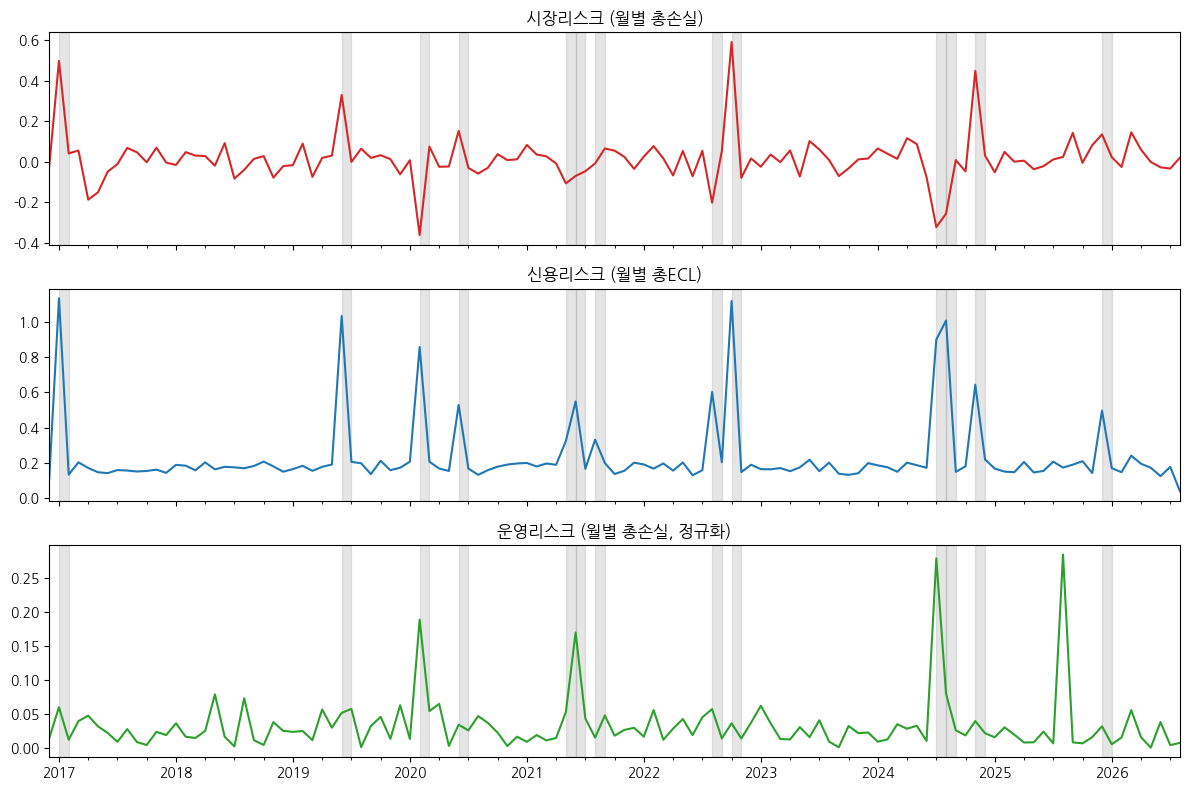

In [10]:
# ============================================================
# [Cell 1 - 재수정] 3개 리스크 데이터 생성 + 월별 집계 + 공통 위기요인 추가
# ============================================================
np.random.seed(42)

N_DAYS = 2520  # 10년치 영업일
dates = pd.bdate_range(end=pd.Timestamp.today(), periods=N_DAYS)

# ------------------------------------------------------------
# 1) 시장리스크: 일별 손실률
# ------------------------------------------------------------
market_returns_daily = stats.t.rvs(df=5, loc=0, scale=0.01, size=N_DAYS)
market_loss_daily = -market_returns_daily

# ------------------------------------------------------------
# 2) 신용리스크: 일별 ECL (시장과 40% 연동 + 고유요인)
# ------------------------------------------------------------
credit_idiosyncratic_daily = np.random.gamma(shape=2.0, scale=0.005, size=N_DAYS)
credit_loss_daily = 0.4 * np.clip(market_loss_daily, 0, None) + 0.6 * credit_idiosyncratic_daily

# ------------------------------------------------------------
# 3) 운영리스크: 일별 손실 (LDA 방식)
# ------------------------------------------------------------
daily_freq = np.random.poisson(lam=0.3, size=N_DAYS)
op_loss_daily = np.zeros(N_DAYS)
for i in range(N_DAYS):
    if daily_freq[i] > 0:
        severities = np.random.lognormal(mean=8, sigma=1.5, size=daily_freq[i])
        op_loss_daily[i] = severities.sum()

daily_df = pd.DataFrame({
    'market_loss': market_loss_daily,
    'credit_loss': credit_loss_daily,
    'op_loss': op_loss_daily
}, index=dates)

# ------------------------------------------------------------
# 월별 집계
# ------------------------------------------------------------
risk_df = daily_df.resample('ME').sum()
risk_df['op_loss'] = risk_df['op_loss'] / risk_df['op_loss'].max() * risk_df['market_loss'].std() * 5

# ------------------------------------------------------------
# ★ 공통 위기요인(systemic crisis factor) 추가 ★
# ------------------------------------------------------------
# 매달 5% 확률로 "위기 국면" 발생 (10년 = 120개월 중 약 6개월 정도)
n_months = len(risk_df)
crisis_prob = 0.05
is_crisis = np.random.binomial(1, crisis_prob, size=n_months)

# 위기 심각도: 위기가 발생한 달마다 다른 강도로 (2~6배 증폭)
# 세 리스크 모두 "같은 심각도 값"을 공유 -> 이게 꼬리의존성을 만드는 핵심 장치
crisis_severity = np.random.uniform(2.0, 6.0, size=n_months)
crisis_multiplier = 1 + is_crisis * (crisis_severity - 1)

risk_df['market_loss'] = risk_df['market_loss'] * crisis_multiplier
risk_df['credit_loss'] = risk_df['credit_loss'] * crisis_multiplier
risk_df['op_loss'] = risk_df['op_loss'] * crisis_multiplier

print(f"월별 집계 완료: 총 {len(risk_df)}개월")
print(f"위기 국면 발생 개월 수: {is_crisis.sum()}개월 ({is_crisis.sum()/n_months*100:.1f}%)")
print(risk_df.describe())
print(f"\n월별 운영리스크 중 0인 달의 비율: {(risk_df['op_loss']==0).mean()*100:.1f}%")
print("\n리스크 간 단순 상관계수:")
print(risk_df.corr())

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
colors = ['tab:red', 'tab:blue', 'tab:green']
titles = ['시장리스크 (월별 총손실)', '신용리스크 (월별 총ECL)', '운영리스크 (월별 총손실, 정규화)']
cols = ['market_loss', 'credit_loss', 'op_loss']
for ax, col, color, title in zip(axes, cols, colors, titles):
    risk_df[col].plot(ax=ax, color=color, title=title)
    # 위기 발생 달에 회색 배경 표시
    crisis_dates = risk_df.index[is_crisis == 1]
    for cd in crisis_dates:
        ax.axvspan(cd - pd.Timedelta(days=15), cd + pd.Timedelta(days=15), color='gray', alpha=0.2)
plt.tight_layout()
plt.show()

의사관측치(pseudo-observation) 요약 통계:
         u_market    u_credit        u_op
count  117.000000  117.000000  117.000000
mean     0.500000    0.500000    0.500000
std      0.287449    0.287449    0.287449
min      0.008475    0.008475    0.008475
25%      0.254237    0.254237    0.254237
50%      0.500000    0.500000    0.500000
75%      0.745763    0.745763    0.745763
max      0.991525    0.991525    0.991525


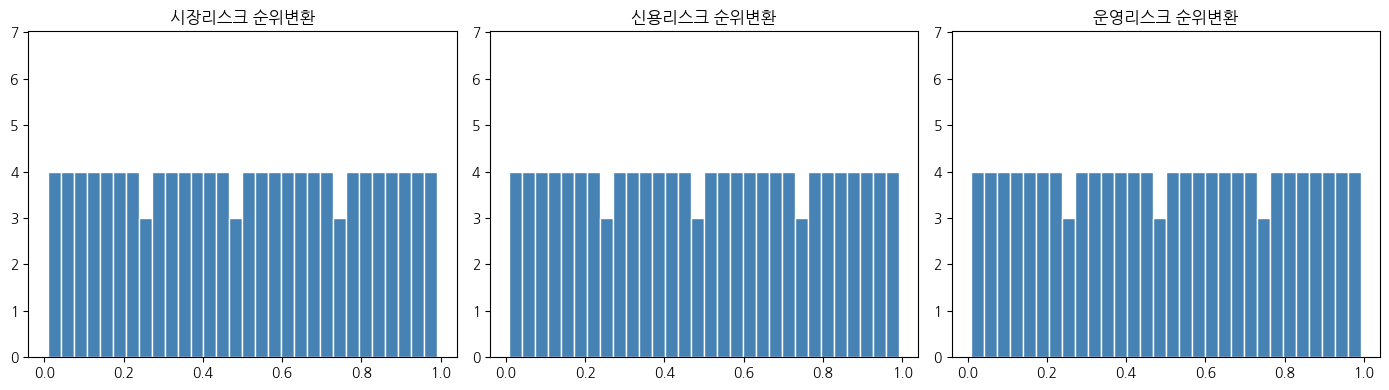

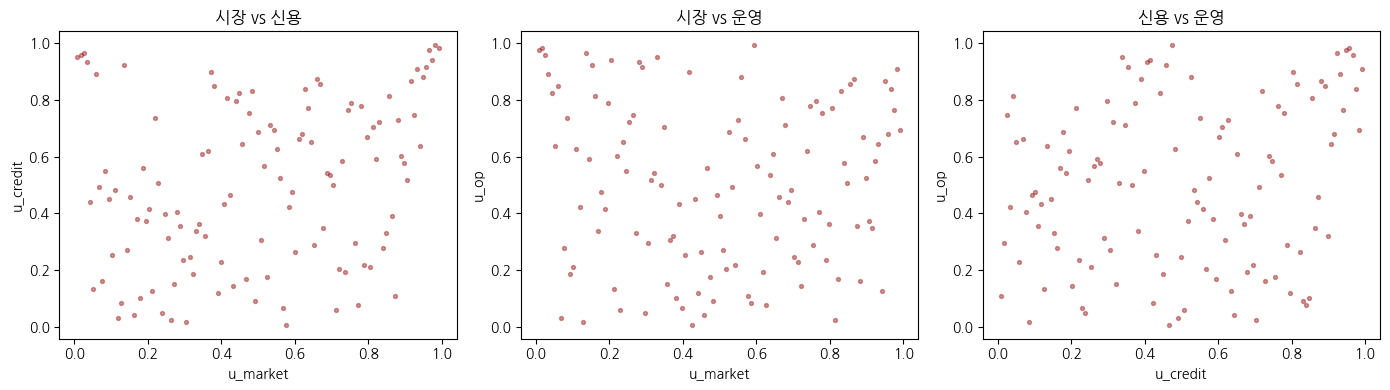


순위 기반 상관계수 (Spearman's rho):
          u_market  u_credit      u_op
u_market  1.000000  0.259745 -0.046666
u_credit  0.259745  1.000000  0.196541
u_op     -0.046666  0.196541  1.000000


In [11]:
# ============================================================
# [Cell 2] 마진분포 균일화 (Pseudo-observation 생성)
# ============================================================
from scipy.stats import rankdata

def to_pseudo_obs(x):
    # rankdata: 값이 작은 것부터 순서대로 순위를 매김 (동점은 평균순위 처리)
    # 순위를 (n+1)로 나누는 이유: 순위가 1~n일 때 그대로 n으로 나누면
    # 최댓값이 정확히 1.0이 되어버려 이후 분포 계산(로그 등)에서 오류가 날 수 있음
    # → (n+1)로 나눠 값의 범위를 (0, 1) 열린구간으로 만듦
    n = len(x)
    return rankdata(x) / (n + 1)

u_market = to_pseudo_obs(risk_df['market_loss'].values)
u_credit = to_pseudo_obs(risk_df['credit_loss'].values)
u_op = to_pseudo_obs(risk_df['op_loss'].values)

pseudo_obs = pd.DataFrame({
    'u_market': u_market,
    'u_credit': u_credit,
    'u_op': u_op
}, index=risk_df.index)

print("의사관측치(pseudo-observation) 요약 통계:")
print(pseudo_obs.describe())
# 정상적으로 변환됐다면 평균이 약 0.5, min/max가 0과 1에 가까운 값이어야 함

# ------------------------------------------------------------
# 검증 1: 각 변수가 실제로 균일분포(0~1)를 따르는지 히스토그램으로 확인
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, title in zip(axes,
                           ['u_market', 'u_credit', 'u_op'],
                           ['시장리스크 순위변환', '신용리스크 순위변환', '운영리스크 순위변환']):
    ax.hist(pseudo_obs[col], bins=30, color='steelblue', edgecolor='white')
    ax.set_title(title)
    ax.set_ylim(0, len(pseudo_obs) * 0.06)  # 균일분포라면 막대 높이가 전체적으로 비슷해야 함
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 검증 2: 변환 후에도 리스크 간 의존구조(상관관계)가 유지되는지 산점도로 확인
# ------------------------------------------------------------
# 코풀라가 실제로 포착하려는 것이 바로 이 산점도의 '모양'입니다
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
pairs = [('u_market', 'u_credit', '시장 vs 신용'),
         ('u_market', 'u_op', '시장 vs 운영'),
         ('u_credit', 'u_op', '신용 vs 운영')]
for ax, (x, y, title) in zip(axes, pairs):
    ax.scatter(pseudo_obs[x], pseudo_obs[y], s=8, alpha=0.4, color='darkred')
    ax.set_title(title)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
plt.tight_layout()
plt.show()

# 스피어만 순위상관계수 (코풀라 파라미터 추정에 직접 활용될 값)
print("\n순위 기반 상관계수 (Spearman's rho):")
print(pseudo_obs.corr(method='spearman'))

Gaussian Copula 상관행렬:
        market  credit      op
market  1.0000  0.2426 -0.0754
credit  0.2426  1.0000  0.2451
op     -0.0754  0.2451  1.0000


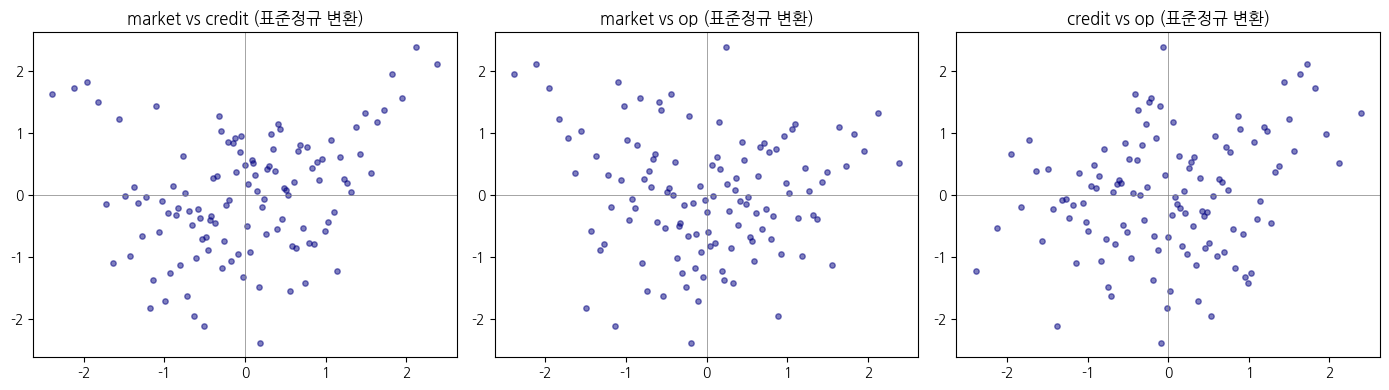


Gaussian Copula 로그우도(Log-likelihood): 8.39
(값이 클수록—0에 가까울수록—적합도가 좋음. 4단계 t-copula와 비교 예정)


In [12]:
# ============================================================
# [Cell 3] Gaussian Copula 적합
# ============================================================
from scipy.stats import norm

# ------------------------------------------------------------
# 1) 의사관측치(0~1)를 표준정규분포 값으로 역변환
# ------------------------------------------------------------
# norm.ppf: 정규분포의 역함수(quantile function)
# 예) u=0.5 -> 0 (정규분포 중앙값), u=0.975 -> 약 1.96 (상위 2.5%)
z_market = norm.ppf(pseudo_obs['u_market'])
z_credit = norm.ppf(pseudo_obs['u_credit'])
z_op = norm.ppf(pseudo_obs['u_op'])

Z = np.column_stack([z_market, z_credit, z_op])  # (117, 3) 행렬로 결합

# ------------------------------------------------------------
# 2) 상관행렬 추정 (Gaussian copula의 유일한 파라미터)
# ------------------------------------------------------------
# 표준정규로 변환된 값들의 피어슨 상관계수 = Gaussian copula의 상관행렬
corr_gaussian = np.corrcoef(Z.T)

corr_df = pd.DataFrame(corr_gaussian,
                        index=['market', 'credit', 'op'],
                        columns=['market', 'credit', 'op'])
print("Gaussian Copula 상관행렬:")
print(corr_df.round(4))

# ------------------------------------------------------------
# 3) 시각화: 정규화된 변수들의 산점도 (선형 관계로 보이는지 확인)
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
pairs = [(0, 1, 'market vs credit'), (0, 2, 'market vs op'), (1, 2, 'credit vs op')]
for ax, (i, j, title) in zip(axes, pairs):
    ax.scatter(Z[:, i], Z[:, j], s=15, alpha=0.5, color='navy')
    ax.set_title(f'{title} (표준정규 변환)')
    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4) Gaussian copula 로그우도 계산 (모형 적합도 참고용, 4단계에서 t-copula와 비교)
# ------------------------------------------------------------
from scipy.stats import multivariate_normal

def gaussian_copula_loglik(Z, corr):
    n = Z.shape[0]
    d = Z.shape[1]
    mvn_density = multivariate_normal.logpdf(Z, mean=np.zeros(d), cov=corr)
    marginal_density = norm.logpdf(Z).sum(axis=1)
    # 코풀라 밀도 = 결합밀도 / 각 주변밀도의 곱 (로그 스케일에서는 차)
    return np.sum(mvn_density - marginal_density)

ll_gaussian = gaussian_copula_loglik(Z, corr_gaussian)
print(f"\nGaussian Copula 로그우도(Log-likelihood): {ll_gaussian:.2f}")
print("(값이 클수록—0에 가까울수록—적합도가 좋음. 4단계 t-copula와 비교 예정)")

t-Copula 최적 자유도(nu): 5.23
t-Copula 로그우도: 11.39
Gaussian Copula 로그우도: 8.39

로그우도 차이(t - Gaussian): 3.00
(양수이고 클수록 t-copula가 꼬리의존성을 더 잘 설명한다는 의미)

→ 자유도 5.2은(는) 뚜렷한 꼬리의존성을 시사합니다.
  (자유도가 낮을수록 극단적 동반 리스크 가능성이 높다는 의미)


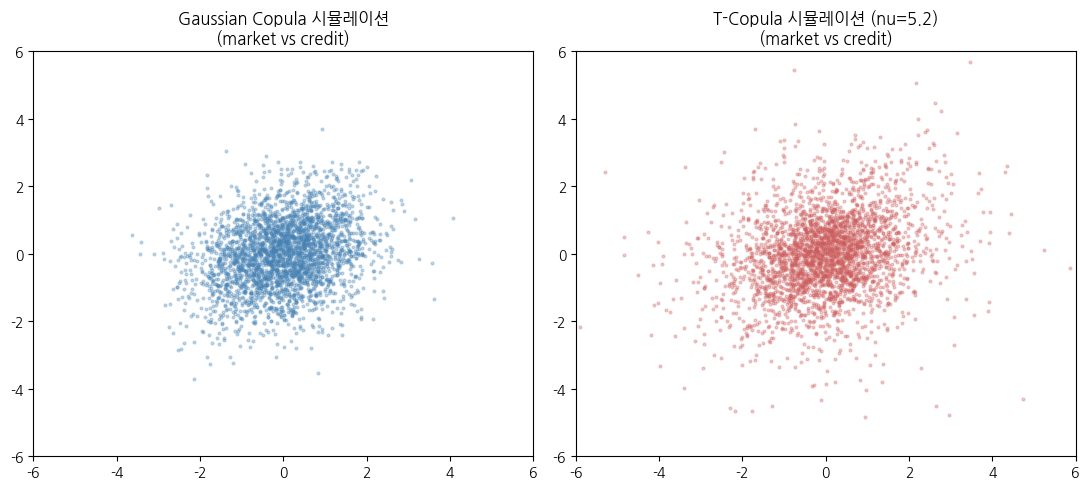

In [13]:
# ============================================================
# [Cell 4] t-Copula 적합 (자유도 MLE 추정) 및 Gaussian과 비교
# ============================================================
from scipy.stats import t as student_t
from scipy.optimize import minimize_scalar

def t_copula_loglik(Z, corr, nu):
    """
    t-copula의 로그우도 계산
    Z: 표준정규 변환값이 아니라, 여기서는 상관행렬 추정을 위해 그대로 사용
       (t-copula는 상관행렬을 Z의 상관계수로 근사하고, nu만 별도로 MLE 추정하는
        간이 방식(IFM, Inference for Margins)을 사용함 — 실무에서 흔히 쓰는 방법)
    corr: 상관행렬 (Gaussian 단계에서 구한 것을 재사용)
    nu: 자유도
    """
    n, d = Z.shape

    # 1) 의사관측치(u)를 t분포 역함수로 변환해야 하므로, 정규분포 기반 Z를
    #    다시 균일분포(u)로 되돌린 뒤 t분포 역함수 적용
    U = norm.cdf(Z)
    U = np.clip(U, 1e-6, 1 - 1e-6)  # 수치 안정성을 위해 0, 1 근처 값 살짝 조정
    T = student_t.ppf(U, df=nu)  # 표준정규 대신 t분포 quantile로 변환

    # 2) 다변량 t분포 로그밀도 계산 (직접 구현 - scipy에 다변량 t가 없어서 수식으로 계산)
    corr_inv = np.linalg.inv(corr)
    corr_det = np.linalg.det(corr)

    # 다변량 t분포 로그밀도 공식
    from scipy.special import gammaln
    quad_form = np.sum((T @ corr_inv) * T, axis=1)  # 마할라노비스 거리 제곱
    log_num = gammaln((nu + d) / 2) - gammaln(nu / 2) - 0.5 * np.log(corr_det) - (d / 2) * np.log(nu * np.pi)
    log_density_mvt = log_num - ((nu + d) / 2) * np.log(1 + quad_form / nu)

    # 3) 각 변수별 단변량 t분포 로그밀도 (분모에서 빼줄 부분)
    log_density_marginal_t = student_t.logpdf(T, df=nu).sum(axis=1)

    # 코풀라 로그우도 = 결합밀도 - 각 주변밀도의 곱
    return np.sum(log_density_mvt - log_density_marginal_t)

# ------------------------------------------------------------
# 자유도(nu)를 3~30 범위에서 로그우도가 최대가 되는 지점으로 탐색
# ------------------------------------------------------------
result = minimize_scalar(
    lambda nu: -t_copula_loglik(Z, corr_gaussian, nu),  # 음수화해서 최소화 = 원래 값 최대화
    bounds=(2.5, 30),
    method='bounded'
)
nu_optimal = result.x
ll_t = -result.fun

print(f"t-Copula 최적 자유도(nu): {nu_optimal:.2f}")
print(f"t-Copula 로그우도: {ll_t:.2f}")
print(f"Gaussian Copula 로그우도: {ll_gaussian:.2f}")
print(f"\n로그우도 차이(t - Gaussian): {ll_t - ll_gaussian:.2f}")
print("(양수이고 클수록 t-copula가 꼬리의존성을 더 잘 설명한다는 의미)")

# ------------------------------------------------------------
# 해석 가이드 출력
# ------------------------------------------------------------
if nu_optimal < 10:
    print(f"\n→ 자유도 {nu_optimal:.1f}은(는) 뚜렷한 꼬리의존성을 시사합니다.")
    print("  (자유도가 낮을수록 극단적 동반 리스크 가능성이 높다는 의미)")
else:
    print(f"\n→ 자유도 {nu_optimal:.1f}은(는) 상대적으로 Gaussian에 가까운 결과입니다.")

# ------------------------------------------------------------
# 시각화: Gaussian vs t-copula 시뮬레이션 산점도 비교 (market-credit 쌍)
# ------------------------------------------------------------
np.random.seed(1)
n_sim = 3000

# Gaussian copula 시뮬레이션
sim_gaussian = np.random.multivariate_normal(np.zeros(3), corr_gaussian, size=n_sim)

# t-copula 시뮬레이션: 다변량정규 / sqrt(카이제곱/자유도)로 생성하는 표준적 방법
chi2_sample = np.random.chisquare(nu_optimal, size=n_sim)
sim_t = sim_gaussian * np.sqrt(nu_optimal / chi2_sample)[:, None]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].scatter(sim_gaussian[:, 0], sim_gaussian[:, 1], s=4, alpha=0.3, color='steelblue')
axes[0].set_title('Gaussian Copula 시뮬레이션\n(market vs credit)')
axes[1].scatter(sim_t[:, 0], sim_t[:, 1], s=4, alpha=0.3, color='indianred')
axes[1].set_title(f'T-Copula 시뮬레이션 (nu={nu_optimal:.1f})\n(market vs credit)')
for ax in axes:
    ax.set_xlim(-6, 6)
    ax.set_ylim(-6, 6)
plt.tight_layout()
plt.show()

=== 개별 리스크 99% VaR (월간 기준) ===
시장리스크 VaR: 0.4891
신용리스크 VaR: 1.1045
운영리스크 VaR: 0.2644

=== 통합 99% VaR 비교 ===
(a) 단순합산 (완전상관 가정, 분산효과 0%): 1.8579
(b) Gaussian Copula 통합 VaR: 1.2180  (분산효과 34.4%)
(c) t-Copula 통합 VaR:        1.2799  (분산효과 31.1%)

Gaussian 대비 t-copula가 산출한 추가 필요자본: 5.1%
(양수라면: Gaussian만 썼을 때 실제 필요한 자본을 과소평가했다는 의미)


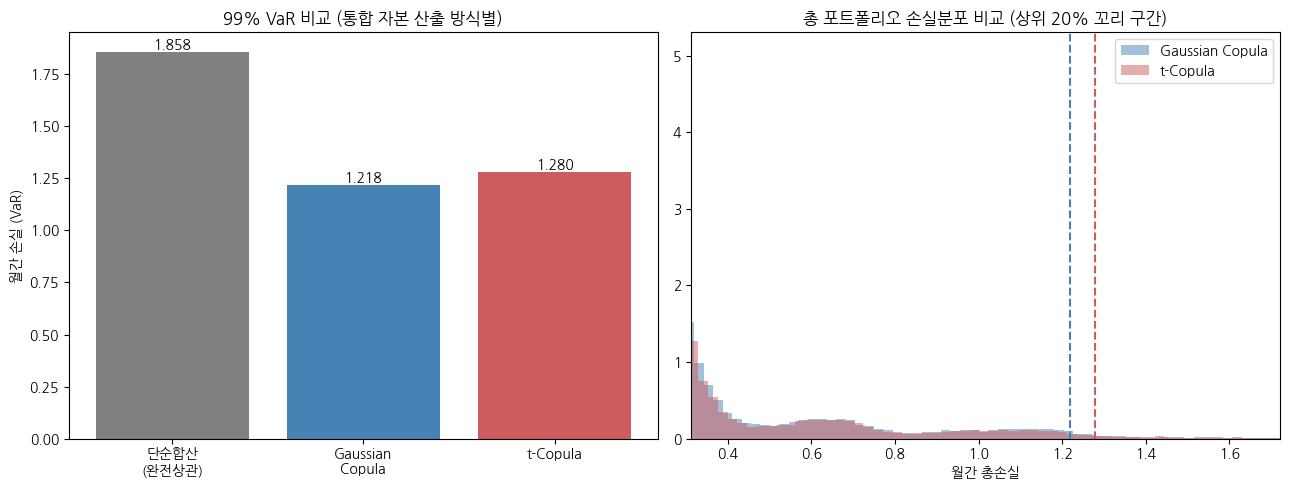

In [14]:
# ============================================================
# [Cell 5] 몬테카를로 결합 시뮬레이션 및 통합 VaR/자본 산출
# ============================================================
N_SIM = 100_000  # 시뮬레이션 횟수 (많을수록 VaR 추정이 안정적)
np.random.seed(7)

# ------------------------------------------------------------
# 1) Gaussian Copula에서 균일분포(U) 시뮬레이션
# ------------------------------------------------------------
sim_z_gaussian = np.random.multivariate_normal(np.zeros(3), corr_gaussian, size=N_SIM)
sim_u_gaussian = norm.cdf(sim_z_gaussian)  # 표준정규 -> 균일분포(0~1) 변환

# ------------------------------------------------------------
# 2) t-Copula에서 균일분포(U) 시뮬레이션
# ------------------------------------------------------------
chi2_sample = np.random.chisquare(nu_optimal, size=N_SIM)
sim_t_raw = sim_z_gaussian * np.sqrt(nu_optimal / chi2_sample)[:, None]  # 다변량 t 생성
sim_u_t = student_t.cdf(sim_t_raw, df=nu_optimal)  # t분포 -> 균일분포(0~1) 변환

# ------------------------------------------------------------
# 3) 균일분포(U) -> 실제 손실 단위로 역변환 (경험적 분위함수, empirical quantile)
# ------------------------------------------------------------
# 이유: 각 리스크의 실제 분포(시장=팻테일 수익률, 신용=ECL, 운영=손실액)가
#       서로 다른 모양이므로, 과거 데이터의 순서를 그대로 이용해
#       "이 리스크가 상위 몇 %에 해당하는 손실인가"를 실제 금액으로 매핑함
def empirical_inverse(u, historical_values):
    # np.quantile의 선형보간(interpolation) 방식을 이용한 경험적 분위함수
    sorted_vals = np.sort(historical_values)
    n = len(sorted_vals)
    idx = u * (n - 1)  # u=0~1을 인덱스 범위(0~n-1)로 매핑
    idx_low = np.floor(idx).astype(int)
    idx_high = np.ceil(idx).astype(int)
    frac = idx - idx_low
    return sorted_vals[idx_low] * (1 - frac) + sorted_vals[idx_high] * frac

def simulate_losses(sim_u):
    market_sim = empirical_inverse(sim_u[:, 0], risk_df['market_loss'].values)
    credit_sim = empirical_inverse(sim_u[:, 1], risk_df['credit_loss'].values)
    op_sim = empirical_inverse(sim_u[:, 2], risk_df['op_loss'].values)
    total_sim = market_sim + credit_sim + op_sim
    return market_sim, credit_sim, op_sim, total_sim

market_g, credit_g, op_g, total_gaussian = simulate_losses(sim_u_gaussian)
market_t, credit_t, op_t, total_t = simulate_losses(sim_u_t)

# ------------------------------------------------------------
# 4) VaR 산출 (99% 신뢰수준: 손실이 이 값을 넘을 확률이 1%)
# ------------------------------------------------------------
confidence = 0.99

var_market = np.quantile(risk_df['market_loss'], confidence)
var_credit = np.quantile(risk_df['credit_loss'], confidence)
var_op = np.quantile(risk_df['op_loss'], confidence)
var_naive_sum = var_market + var_credit + var_op  # 완전상관 가정 (분산효과 없음)

var_gaussian = np.quantile(total_gaussian, confidence)
var_t = np.quantile(total_t, confidence)

print(f"=== 개별 리스크 99% VaR (월간 기준) ===")
print(f"시장리스크 VaR: {var_market:.4f}")
print(f"신용리스크 VaR: {var_credit:.4f}")
print(f"운영리스크 VaR: {var_op:.4f}")

print(f"\n=== 통합 99% VaR 비교 ===")
print(f"(a) 단순합산 (완전상관 가정, 분산효과 0%): {var_naive_sum:.4f}")
print(f"(b) Gaussian Copula 통합 VaR: {var_gaussian:.4f}  (분산효과 {(1-var_gaussian/var_naive_sum)*100:.1f}%)")
print(f"(c) t-Copula 통합 VaR:        {var_t:.4f}  (분산효과 {(1-var_t/var_naive_sum)*100:.1f}%)")
print(f"\nGaussian 대비 t-copula가 산출한 추가 필요자본: {(var_t/var_gaussian - 1)*100:.1f}%")
print("(양수라면: Gaussian만 썼을 때 실제 필요한 자본을 과소평가했다는 의미)")

# ------------------------------------------------------------
# 5) 시각화: 세 가지 VaR 비교 막대그래프 + 손실분포 비교
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (좌) VaR 비교 막대그래프
labels = ['단순합산\n(완전상관)', 'Gaussian\nCopula', 't-Copula']
values = [var_naive_sum, var_gaussian, var_t]
colors_bar = ['gray', 'steelblue', 'indianred']
bars = axes[0].bar(labels, values, color=colors_bar)
axes[0].set_title('99% VaR 비교 (통합 자본 산출 방식별)')
axes[0].set_ylabel('월간 손실 (VaR)')
for bar, v in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v, f'{v:.3f}',
                 ha='center', va='bottom', fontsize=10)

# (우) Gaussian vs t 총손실 분포 비교 (꼬리 부분 확대)
axes[1].hist(total_gaussian, bins=100, alpha=0.5, color='steelblue', label='Gaussian Copula', density=True)
axes[1].hist(total_t, bins=100, alpha=0.5, color='indianred', label='t-Copula', density=True)
axes[1].axvline(var_gaussian, color='steelblue', linestyle='--', lw=1.5)
axes[1].axvline(var_t, color='indianred', linestyle='--', lw=1.5)
axes[1].set_xlim(np.percentile(total_gaussian, 80), np.percentile(total_t, 99.9))
axes[1].set_title('총 포트폴리오 손실분포 비교 (상위 20% 꼬리 구간)')
axes[1].set_xlabel('월간 총손실')
axes[1].legend()

plt.tight_layout()
plt.show()